In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../notebooks/my_datasets/winequality-red.csv')

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [5]:
df.duplicated().sum()

np.int64(240)

In [6]:
df = df.drop_duplicates()

In [7]:
df.corr(numeric_only=True)['quality'].sort_values()

volatile acidity       -0.395214
density                -0.184252
total sulfur dioxide   -0.177855
chlorides              -0.130988
pH                     -0.055245
free sulfur dioxide    -0.050463
residual sugar          0.013640
fixed acidity           0.119024
citric acid             0.228057
sulphates               0.248835
alcohol                 0.480343
quality                 1.000000
Name: quality, dtype: float64

<Axes: xlabel='alcohol', ylabel='quality'>

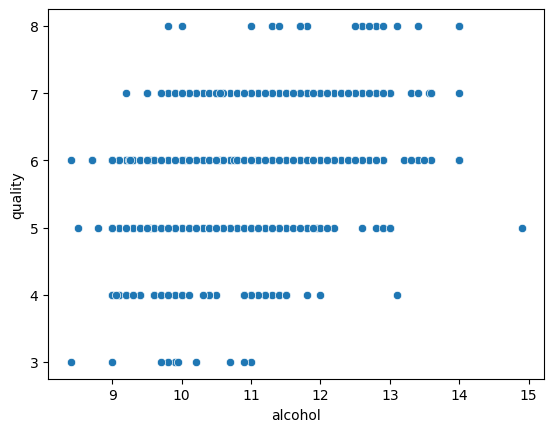

In [8]:
sns.scatterplot(x='alcohol', y='quality', data=df)

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X = df.drop('quality', axis=1)
y = df['quality']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.17, random_state=42)

In [12]:
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

In [13]:
import optuna

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 10),
    }

    model = XGBRegressor(**params, random_state=42)

    score = cross_val_score(
        model, X, y,
        cv=5,
        scoring="neg_root_mean_squared_error"
    ).mean()

    return -score  

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best params:", study.best_params)
    

C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-17 15:19:36,463] A new study created in memory with name: no-name-2c1de811-642b-4094-a493-212026b1c09b
[I 2026-03-17 15:19:39,663] Trial 0 finished with value: 0.6792594075202942 and parameters: {'n_estimators': 716, 'max_depth': 6, 'learning_rate': 0.04919866155933979, 'subsample': 0.7824964902432001, 'colsample_bytree': 0.6957139710718582, 'reg_alpha': 0.9580455925982543, 'reg_lambda': 1.4252414861448832}. Best is trial 0 with value: 0.6792594075202942.
[I 2026-03-17 15:19:41,626] Trial 1 finished with value: 0.6939979791641235 and parameters: {'n_estimators': 434, 'max_depth': 5, 'learning_rate': 0.09991533478063738, 'subsample': 0.7143403083518882, 'colsample_bytree': 0.6106676432173709, 'reg_alpha'

Best params: {'n_estimators': 325, 'max_depth': 3, 'learning_rate': 0.02732678139591605, 'subsample': 0.8991727317398026, 'colsample_bytree': 0.7362446237434841, 'reg_alpha': 0.022770575831550732, 'reg_lambda': 9.926091890679032}


In [14]:
best_params = study.best_params

final_model = XGBRegressor(
    **best_params,
    random_state=42
)

In [15]:
final_model.fit(X_test, y_test)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7362446237434841
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


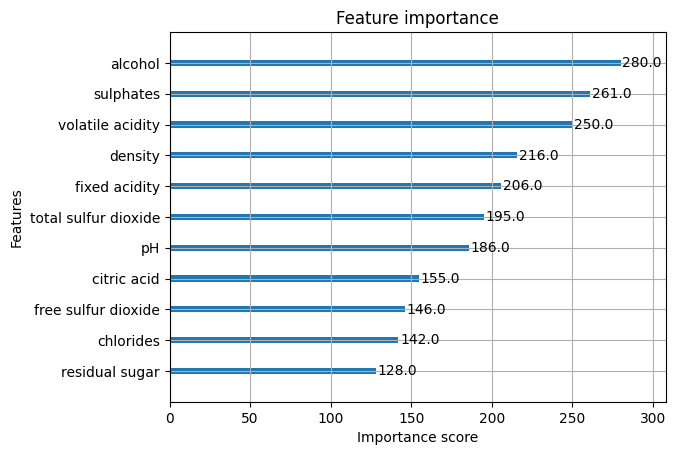

In [16]:
from xgboost import plot_importance

plot_importance(final_model)
plt.show()

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

In [18]:
from sklearn.metrics import mean_squared_error

In [19]:
y_pred = final_model.predict(X_test)

In [20]:
MSE = mean_squared_error(y_test, y_pred)

In [21]:
MSE

0.11471955478191376

In [22]:
RMSE = np.sqrt(MSE)
RMSE

np.float64(0.33870275284076706)

In [23]:
from sklearn.metrics import mean_absolute_percentage_error

In [24]:
mean_absolute_percentage_error(y_test, y_pred)

0.04819181188941002